In [1]:
import gzip
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:

with gzip.open('../data/train-images-idx3-ubyte.gz','r') as fin:
    data = fin.read()
with gzip.open('../data/train-labels-idx1-ubyte.gz','r') as fin:
    labels = fin.read()


In [3]:
def get_label(data: list[bytes], index: int) -> int:
    magic_number = int.from_bytes(data[0:4])
    assert magic_number == 2049
    n_images = int.from_bytes(data[4:8])
    assert index > 0, f"dataset has index from {0} to {n_images - 1}. {index} given"
    assert index < n_images, f"dataset has index from {0} to {n_images - 1}. {index} given"
    return int(data[8 + index])


In [4]:
def get_image(data: list[bytes], index: int) -> list[list[float]]:
    magic_number = int.from_bytes(data[0:4])
    assert magic_number == 2051, "File is not an image dataset file"
    n_images = int.from_bytes(data[4:8])
    assert index > 0, f"dataset has index from {0} to {n_images - 1}. {index} given"
    assert index < n_images, f"dataset has index from {0} to {n_images - 1}. {index} given"
    n_rows = int.from_bytes(data[8:12])
    n_cols = int.from_bytes(data[12:16])
    img = data[((index * image_size) + start):(start + image_size + (index * image_size))]
    img2d = [
        [int(pixel)/255 for pixel in img[(i * n_rows):((i + 1) * n_rows)]]  for i in range(n_cols)
    ]
    return img2d


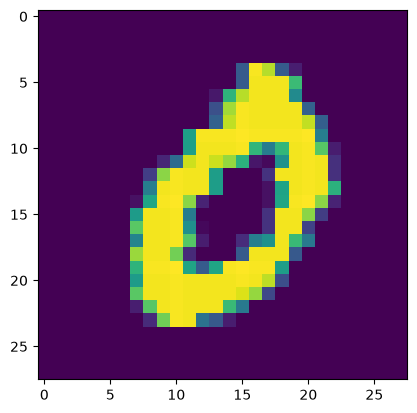

In [5]:

int.from_bytes(data[:4])
n_rows = int.from_bytes(data[8:12])
n_cols = int.from_bytes(data[12:16])
image_size = n_rows * n_cols
start = 16
img_count = 37
img = data[((img_count * image_size) + start):(start + image_size + (img_count * image_size))]
plt.imshow(np.array([k for k in img]).reshape(n_rows, n_cols) / 255)

In [30]:
RUN = "logs/2026-08-07 15:26:09.715942.txt"
RUN = "logs/2026-08-07 11:02:42.012137.txt"
losses = []
correctnesses = []
with open(RUN) as f:
    for i, line in enumerate(f):
        loss, correctness = line.split("-")
        losses.append(float(loss))
        correctnesses.append(float(correctness))

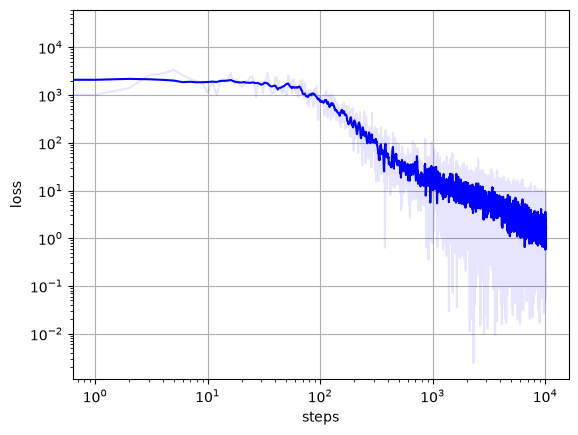

In [32]:
checkpoint_sparsity = 100
window_size = 10
weights = np.ones(window_size) / window_size
sma = np.convolve(losses, weights, mode='valid')

plt.loglog(losses, alpha=.1, color="blue")
plt.loglog(sma, label=f"moving average", alpha=1, color="blue")
plt.xlabel("steps")
plt.ylabel("loss")
for i in range(len(losses) // checkpoint_sparsity):
    # plt.axvline((i + 1) * checkpoint_sparsity, linestyle="dotted")
    pass
plt.grid()
plt.show()

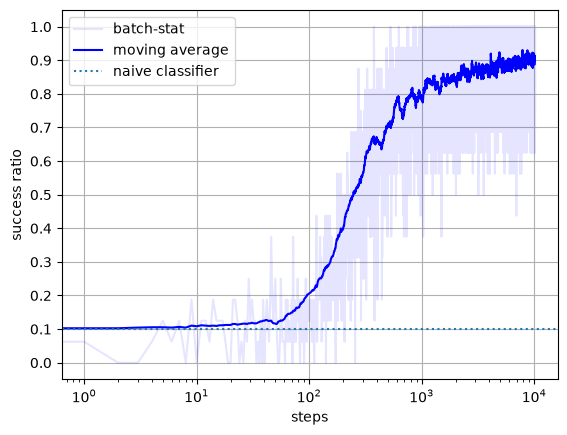

In [34]:
window_size = 64
weights = np.ones(window_size) / window_size
sma = np.convolve(correctnesses, weights, mode='valid')
plt.semilogx(correctnesses, label="batch-stat", alpha=.1, color="blue")
plt.semilogx(sma, label=f"moving average", alpha=1, color="blue")
plt.axhline(.1, label="naive classifier", linestyle="dotted")
plt.xlabel("steps")
plt.yticks([i/10 for i in range(11)])
plt.ylabel("success ratio")
plt.grid()
plt.legend()
plt.show()

In [13]:
CHECKPOINT = "checkpoints/2026-08-07 11:02:42.012137-0-3600.json"
model = json.load(open(CHECKPOINT))
W0, W1 = np.array(model["model_weights"][0]), np.array(model["model_weights"][1])

In [14]:
np.array(get_image(data, 4)).shape

(28, 28)

In [15]:
x =np.array(get_image(data, 4))


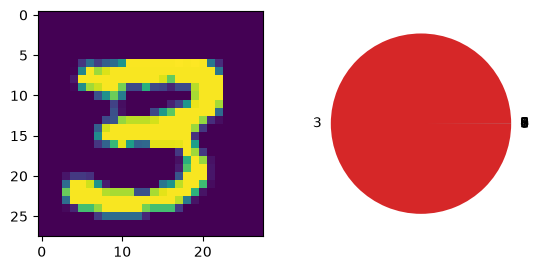

3


In [26]:
def forward(x, model):
    W0, W1 = np.array(model["model_weights"][0]), np.array(model["model_weights"][1])
    activation = x.reshape(784)
    activation = W0.T @ activation
    activation = activation * (activation > 0)
    activation = W1.T @ activation
    return activation


def stable_sigmoid(z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        exp_z = np.exp(z)
        return exp_z / (1 + exp_z)

K = 111
img = get_image(data, K)
label = get_label(labels, K)
out = forward(np.array(img), model)
probs = np.array([stable_sigmoid(o) for o in out])
probs = probs/np.sum(probs)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(img)
axs[1].pie(probs, labels = list(range(len(probs))))
plt.show()
print(label)